<a href="https://colab.research.google.com/github/Vihhycherezass/Detection_Of_Parkinson-s_Disease/blob/main/Detection_Of_Parkinson's_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('./parkinsons.data')
print("Размер датасета: ", df.shape)
print("Первые 5 строк: ")
df.head()

Размер датасета:  (195, 24)
Первые 5 строк: 


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [ ]:
print("Информация о данных: ")
print(df.info())
print("Статистика датасета: ")
print(df.describe())

Информация о данных: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 

In [ ]:
print("Распределение целево переменной: ")
print(df['status'].value_counts())
print("Процентное сосоотношение: ")
print(df['status'].value_counts(normalize=True) * 100)

Распределение целево переменной: 
status
1    147
0     48
Name: count, dtype: int64
Процентное сосоотношение: 
status
1    75.384615
0    24.615385
Name: proportion, dtype: float64


#Дисбаланс классов
После анализа датасета можно заметить, что в нем есть дисбаланс классов.
Больных - 75%, а здоровых - 25%
Это может привести к тому, что в оценка модели будет к примеру 75% точности, сама модель смогла распознать только больных, а здоровых - нет.

In [ ]:
X = df.drop(['name', 'status'], axis=1) #Удаляем столбцы с именем и столбцы с целевой переменной, так как эти данные нам не нужны в обучении модели (name - это просто идентификатор, который не несет в себе никаких данных для обучения, а status - это то, что мы хотим предсказать, то есть это ответы для нащей модели)
y = df['status'] #Целевая переменная!(то, что мы пытаемся предсказать)
print(f"Размер матрицы признаков: {X.shape}")
print(f"Размер целевой переменной: {y.shape}")

Размер матрицы признаков: (195, 22)
Размер целевой переменной: (195,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Процент больных в обучающей выборке: {y_train.mean():.2f}%")
print(f"Процент больных в тестовой выборке: {y_test.mean():.2f}%")
#Получилось разбить данные в равном соотношении больных/здоровых

Обучающая выборка: (156, 22)
Тестовая выборка: (39, 22)
Процент больных в обучающей выборке: 0.76%
Процент больных в тестовой выборке: 0.74%


#Стандартизация
Очень важное понятие в мащинном обучении.
Признаки могут иметь разные масштабы(500, 50, 0.5, 1, 0)
И для того, чтобы наша модель не колебалась, обучалась быстрее и сходилась, а с регуляризацией признаки с большим значением не сильно наказывались, нам нужно использовать стандартизацию.
Стандартизация преобразует данные так, чтобы среднее значение было - 0, а стандартное отклонение - 1.
Использовать стандартизацию нужно после разбиения на обучающую и тестовую выборки. Если мы будем использовать стандартизацию на все данные преред выборкой, то произойдет утечка информации из теста в тренировку.


In [ ]:
scaler = StandardScaler()
X_train_scaled =  scaler.fit_transform(X_train) #Вычисляет параметры и сразу преобразует данные
X_test_scaled = scaler.transform(X_test) #Применяет ранее вычисленные данные

In [ ]:
model = xgb.XGBClassifier(
    random_state = 42,
    n_estimators = 100, #Количество деревьев, которые будут исправлять ошибки один за одним. Нужно понимать, что XGBoost работает таким образом, что каждое новое дерево исправляет ошибки другого, будто студенты, которые работают сообща над задачами, каждый новый студент проверяет работу прошлого и устраняет в ней ошибки. От этого раюота становиться лучше и в ней становиться все меньше ошибко = УВЕЛИЧИВАЕТСЯ ТОЧНОСТЬ!
    max_depth = 3, #Это максимальная глубина деревье. То есть в нашем примере мы смотрим если MDVP:Fo(Hz) > 150? (MDVP:Fo(Hz) - средняя основная частота голоса, у больных Паркинсона наблюдается тремор голоса, поэтому частота выше, чем у здоровых людей), да -> то Jitter > 0.005? (Jitter - это мера нестабильность частоты голоса(дрожание), у больных так же эта мера выше!) или нет -> NHR > 0.03? (NHR - это мера соотношения шума и тона, у больных она так же выше!). И так до третьего уровня, где уже модель решает болен ли пациент или здоров.
    learning_rate = 0.1, #Скорость обучения модели
    subsample = 0.8, #Доля данных для каждого дерева, это нужно чтобы деревья обучались на разных данных, а не на всех, так каждое дерево получает рандомные данные, из-за этого повышается обобщающая способность и создается разнообразие. Если мы поставим 1.0, то модель может переоучиться, а нам это не нужно.
    colsample_bytree = 0.8 #Доля признаков для каждого дерева.
)

model.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точность модели: {accuracy:.4f}, ({accuracy * 100:.2f}%)")


Точность модели: 0.9231, (92.31%)


#Детальный отчет по классификации

In [ ]:
print(classification_report(y_test, y_pred))
#Можно заметить, что модели труднее дается определять здоровых пациентов, я предполагаю, что это из-за дисбаланса классов. Можно попробовать изменить гиперпараметры и получить лучший результат.

              precision    recall  f1-score   support

           0       0.89      0.80      0.84        10
           1       0.93      0.97      0.95        29

    accuracy                           0.92        39
   macro avg       0.91      0.88      0.90        39
weighted avg       0.92      0.92      0.92        39



#Матрица ошибок

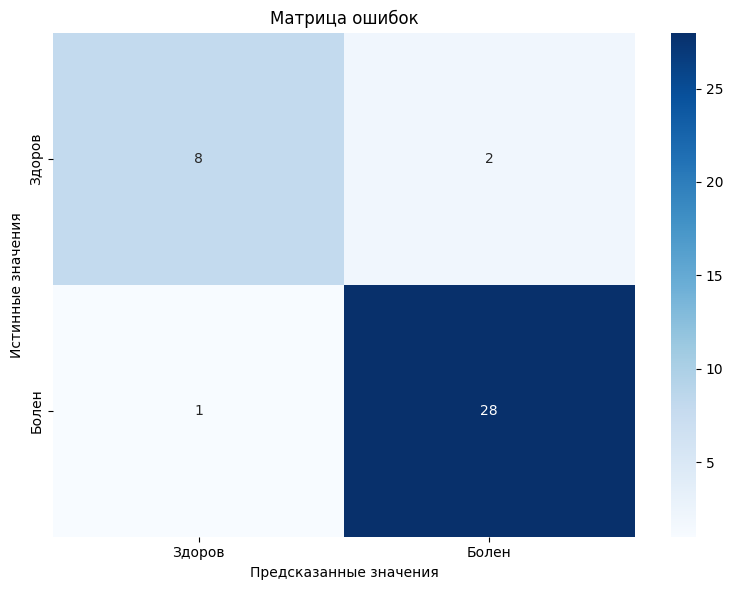

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Здоров', 'Болен'],
            yticklabels=['Здоров','Болен'])
plt.title("Матрица ошибок")
plt.xlabel("Предсказанные значения")
plt.ylabel("Истинные значения")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#Попытка №2
У нас есть дисбаланс данных, нужно попробовать это как-то решить.
Думаю попробовать использовать SMOTE для создания синтетических примеров(вместо копирования он генерирует новые данные), а так же применить кросс-валидацию.





In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=43, stratify=y)
#Создаем пайплайн с SMOTE и XGBoost. Пайплайн - это конвейер, который автоматически выполняет несколько шагов обработки данных и обучения модели в правильной последовательности.
#В нашей задаче пайплайн гарантирует, что масштабирование обучается только на тренировачных данных, smote применяется только к тренировачным данным, модель получает уже обработанные данные, кросс-валидация работает корректно, результаты воспроизводимы.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(
        random_state = 43,
        sampling_strategy = 'auto', #Этот параметр говорит насколько мы хотим увеличить количество примеров в миноритарном классе(Это класс, который встречается реже, в наше случае это здоровый пациент). Значение 'auto' означает, что количество миноритарных примеров будет столько же сколько и мажоритарных.
        k_neighbors=5 #Это количество "друзей", которых SMOTE будет искать для каждого реального привмера миноритарного класса, чтобы создать синтетические примеры. Работает это так: SMOTE берет одного здорового пациента и ищет пять похожих реальных записей, далее он выбирает рандомно одну запись. Получается смесь двух записей, первой и той, которую выбрал SMOTE. Это и есть синтетические примеры.
    )),
    ('xgb', xgb.XGBClassifier(
        n_estimators = 200, #Количество деревьев
        max_depth = 4, #Глубина деревье
        learning_rate = 0.1, #Скорость обучения
        subsample = 0.8,
        colsample_bytree = 0.8,
        reg_alpha = 0.1,  #| L2-регуляризация Штрафует модель за большие значения весов. Не обнуляет признаки, но заставляет их веса быть небольшими.
                          # } Это штрафы за сложность модели. Они помогают бороться с переобучением.
        reg_lambda = 1.0, #| L1-регуляризация Штрафует модель за количество признаков, которые она использует. Поощряет модель полностью обнулять веса для неважных признаков.
        random_state = 43,
        eval_metric = 'logloss' #Это метрика, которую модель использует для самопроверки во время обучечния. Она смотрит на проверочные данные и считате насколько она была "уверена" в своих правильных ответах. Эта метрика штрафует за две вещи: за неправильные ответы, за правильные ответы с низкой уверенностью(если модель сказала что этот пациент здоров с вероятностью 51%, и была права, она все равно получит небольшой штраф за неуверенность).
    ))
])

stratified_cv = StratifiedKFold( #StratifiedKFold - это способ, который разбивает наши данные на несколько частей(фолдов), для проверки модели, который гарантирует что в каждой части соотношение классов (здоровых/больных) будет таким же, как и во всем исходномнаборе данных. Это делает оценку стабильной и надежной
                                n_splits=10, #Это количество фолдов (части, на которые делятся данные). Значение жтого параметра - 10, потому что это является самым популярным и общепринятым выбором. Это значение дает хороший баланс между: смещением(если взять слишком мало фолдов, то обучающая выборка будет большой => может давать большой разброс результатов), дисперсией(если взять слишком много фолдов, то тестовые выборки будут слишком маленькими и похожими друг на друга, оценка станет менее надежной и будет иметь высокую дисперсию)
                                shuffle=True, #Этот параметр перемешивает данные так, чтобы если наш датасет упорядочен по какому-либо атрибуту, то он перемешивался и в обучающей/тестовой выборке были и больные и здоровые, а не только больные или здоровые. Всегда использовать вместе с random_state!
                                random_state=43
                                )
cv_scores = cross_val_score(pipeline, X_train2, y_train2, cv=stratified_cv, scoring='accuracy', n_jobs=-1)
pipeline.fit(X_train2, y_train2)
y_pred2 = pipeline.predict(X_test2)
test_accuracy = accuracy_score(y_test2, y_pred2)
print(f"Точность на тестовой выборке: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Точность на тестовой выборке: 0.8974 (89.74%)


Точность на тестовой выборке составила ~90%
Точность упала и это может быть из-за того, что SMOTE может создавать "шумные" синтетические примеры, особенно, когда данных мало\
Нужно попробовать еще несколько способов

#Попытка №3

Можно попробовать сделать модель без SMOTE, но с другими улучшениями

In [ ]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(X, y, test_size=0.2, random_state=44, stratify=y)

no_smote_pipline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(
        n_estimators = 200,
        max_depth = 4,
        learning_rate = 0.1,
        subsample = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight= 3.0, #Это параметр, который заставляет модель больше обращать внимания на ошибки, которая она делает в миноритарном классе. Ошибка в миноритарном классе > чем ошибка в мажоритарном. Используем значени 3.0 так как это значение можно рассчитать по формуле: число_больных/число_здоровых. В нашем случае 147/48 примерно равно 3
        reg_alpha = 0.1,
        reg_lambda = 1.0,
        random_state = 44,
        eval_metric = 'logloss'
    ))
])

no_smote_pipline.fit(X_train3, y_train3)
y_pred_no_smote = no_smote_pipline.predict(X_test3)
no_smote_accuracy = accuracy_score(y_test3, y_pred_no_smote)
print(f'Точность без SMOTE: {no_smote_accuracy:.4f} ({no_smote_accuracy * 100:.4f}%)')

Точность без SMOTE: 0.9487 (94.8718%)


Сейчас результат схож с первой попыткой, все-таки SMOTE сделал "шумные" синтетические примеры.(Надеюсь, что правильно его использовал).


#Попытка №4
Пробую подбирать подходящие гиперпараметры для большей эффективности. Для этого можно использовать RandomizedSearchCV. Мы задаем пространство для поиска, количетсво итераций, для каждой комбинации он проведет кросс-валидацию и выведет лучшую комбинаци гиперпараметров. Так же есть GridSearchCV, но так как мы используем современные и быстрые инструменты, то мы его не берем, так как он медленее.
Например если у нас есть 5 параметров, каждый из которых имеет по 10 значений, то GridSearchCV проверит 10 х 10 х 10 х 10 х 10 = 100.000 комбинаций, а RandomizedSearchCV напимер с n_iter = 100 проверит всего 100 комбинаций, в 1000 раз быстрее!\
P.S разобрался и понял, что GridSearchCV проверяет большее количество комбинаций, поэтому и тратит больше времени, но при этом она находит самую лучшую комбинацию

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
X_train4, X_test4, y_train4, y_test4 = train_test_split(X, y, test_size=0.2, random_state=46, stratify=y)
#Создаем сетку параметров
param_grid = {
    'xgb__n_estimators' : [150, 200, 250, 300, 400],
    'xgb__max_depth' : [3, 4, 5, 6],
    'xgb__learning_rate' : [0.01, 0.05, 0.1, 0.15],
    'xgb__subsample' : [0.7, 0.8, 0.9],
    'xgb__colsample_bytree' : [0.7, 0.8, 0.9],
    'xgb__reg_alpha' : [0, 0.1, 0.5, 1.0],
    'xgb__reg_lambda' : [1.0, 1.5, 2.0],
    'xgb__gamma' : [0, 0.1, 0.2],
    'xgb__scale_pos_weight' : [2.0, 2.5, 3.0, 3.5]
}

grid_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(random_state=46, eval_metric='logloss'))
])

random_search = RandomizedSearchCV(
    grid_pipeline,
    param_distributions=param_grid,
    n_iter = 50, #Задаем количество итераций для подбора лучшей комбинации
    cv=5, #Этот параметр говорит на сколько частей разбивать данные для проверки каждой комбинации параметров (фолды)
    scoring='accuracy', #Это метрика, по которой определяется лучшая модель, какая комбинация параметров лучшая. Мы задаем значение на точность!
    n_jobs = -1, #Используем все доступные ядра процессора для того, чтобы поиск происходил быстрее.
    random_state = 46,
    verbose = 1 #Для более подробного показа процесса обучения
)

random_search.fit(X_train4, y_train4)
print("Лучшие параметры: ")
for param, value in random_search.best_params_.items():
  print(f'{param}: {value}')

random_params_model = random_search.best_estimator_ #best_estimator_ - это готовая модель с лучшими найденными параметрами. Нижнее подчеркивание у таких переменных означает, что это атрибуты, которые вычисляются после обучения. Сделали это для того, чтобы понимать какие параметры задал я, а какие вычислила модель
random_params_accuracy = random_search.best_score_ #best_score_ - это средняя оценка на валидационных фолдах во время кросс-валидации

print(f"Лучшая точность крос-валидации: {random_params_accuracy:.4f} ({random_params_accuracy * 100:.2f}%)")

y_pred_random_params = random_params_model.predict(X_test4)
random_params_test_accuracy = accuracy_score(y_test4, y_pred_random_params)
print(f"Точность на тестовой выборке: {random_params_test_accuracy:.4f}, ({random_params_test_accuracy * 100:.2f}%)")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры: 
xgb__subsample: 0.8
xgb__scale_pos_weight: 2.5
xgb__reg_lambda: 2.0
xgb__reg_alpha: 0
xgb__n_estimators: 300
xgb__max_depth: 6
xgb__learning_rate: 0.15
xgb__gamma: 0
xgb__colsample_bytree: 0.7
Лучшая точность крос-валидации: 0.9484 (94.84%)
Точность на тестовой выборке: 0.9487, (94.87%)


#Ансамблирование с лучшими параметрами
Ансамблирование - это техника, когда мы объединяем несколько моделей в одну команду, чтобы они работали вместе и давали нам более точные предсказания.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_recall_curve

X_train_ensemble, X_test_ensemble, y_train_ensemble, y_test_ensemble = train_test_split(X, y, test_size=0.2, random_state=70, stratify=y)

best_params = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,
    'gamma': 0.1, # минимальное уменьшение значения функции потерь, необходимое для того, чтобы произвести дальнейшее разбиение листа. Если потенциальное улучшение качества от разделения узла меньше, чем значение gamma, то XGBoost откажется делать это разделение. Это помогает в борьбе с переобучением и контролем над сложностью деревьев.
    'scale_pos_weight': 2.5
}

xgb_model = xgb.XGBClassifier(
    **best_params,
    random_state=70,
    eval_metric='logloss'
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=70
)

svm_model = SVC( # Эта модель работает таким образом, что она находит линию между классами в гиперплоскости, максимально удаленную от точек обоих классов.
    probability=True, # Расчет вероятностей принадлежащим классам
    C=1.0, # Параметр регуляризации. Если С=0.1 - может быть недообучение, С=100.0 - может быть переобучение(очень узкая граница), С=1.0 - баланс
    gamma='scale', # 'scale' - автоматически вычисляет значение gamma как: 1 / количество признаков * дисперсия признаков
    random_state=70
)

ensemble_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ensemble', VotingClassifier(
        estimators=[
            ('xgb', xgb_model),
            ('rf', rf_model),
            ('svm', svm_model)
        ],
        voting='soft', # Этот параметр работает как голосование моделей за выбор предсказаний. То модели могут с разным процентом предсказывать болен/не болен и уже на основании суммы их предсказаний делаются выводы. Есть hard голосование, где не учитываются проценты, а голос каждого = 1 ед. голоса, а не сумма процентов.
        n_jobs=-1
    ))
])

ensemble_pipeline.fit(X_train_ensemble, y_train_ensemble)
y_pred_ensemble = ensemble_pipeline.predict(X_test_ensemble)

ensemble_accuracy = accuracy_score(y_test_ensemble, y_pred_ensemble)

print(f"Точность ансамбля: {ensemble_accuracy:.4f} ({ensemble_accuracy:.2f}%)")


Точность ансамбля: 0.9744 (0.97%)


#Матрица ошибок

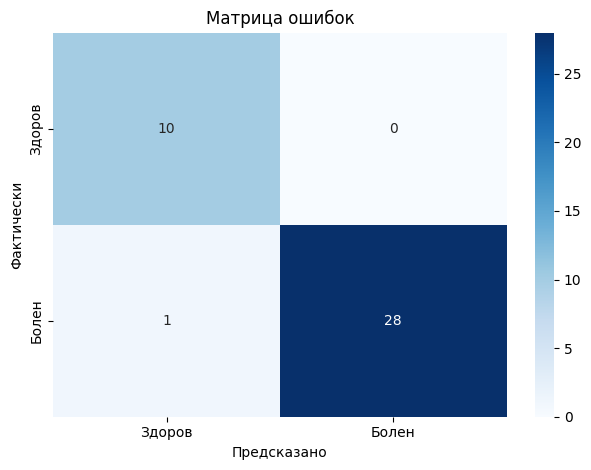

In [ ]:
cm = confusion_matrix(y_test_ensemble, y_pred_ensemble)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Здоров', 'Болен'],
            yticklabels=['Здоров','Болен'])
plt.title("Матрица ошибок")
plt.xlabel('Предсказано')
plt.ylabel('Фактически')
plt.tight_layout()
plt.show()

#Вывод
Обучив модель с данными из датасета с использованием ансамбля, мне удалось достичь результата точности в 97.44%. Во время выполнения данного задания я изучил новые инструменты для предобработки данных(Стандартицазия - StandardScaler), научился создавать синтетические примеры SMOTE при дисбалансе классов, узнал о RandomizedSearchCV, GridSearchCV для поиска лучшей комбинации для параметров модели, а так же узнал про ансамбли и pipeline.